In [2]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt


In [7]:
df = pl.read_csv("C:/Users/yaoze/Downloads/flights_sample_3m.csv", infer_schema_length=10000,
    ignore_errors=True)
print(df.shape)
df.describe()

(3000000, 32)


statistic,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
str,str,str,str,str,f64,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""3000000""","""3000000""","""3000000""","""3000000""",3e6,3e6,"""3000000""","""3000000""","""3000000""","""3000000""",3e6,2.922385e6,2.922356e6,2.921194e6,2.921194e6,2.920056e6,2.920056e6,3e6,2.920058e6,2.913802e6,3e6,"""79140""",3e6,2.999986e6,2.913802e6,2.913802e6,3e6,533863.0,533863.0,533863.0,533863.0,533863.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,0.0,"""0""","""0""","""0""","""0""",0.0,77615.0,77644.0,78806.0,78806.0,79944.0,79944.0,0.0,79942.0,86198.0,0.0,"""2920860""",0.0,14.0,86198.0,86198.0,0.0,2.466137e6,2.466137e6,2.466137e6,2.466137e6,2.466137e6
"""mean""",null,null,null,null,19976.294095,2511.535519,null,null,null,null,1327.061984,1329.775913,10.123326,16.643046,1352.360989,1462.499569,7.678982,1490.560665,1466.511162,4.260858,0.02638,null,0.002352,142.275807,136.620541,112.31084,809.361552,24.759086,3.98526,13.164728,0.145931,25.471282
"""std""",null,null,null,null,377.284619,1747.25804,null,null,null,null,485.878854,499.310052,49.251835,9.192901,500.872687,527.236818,6.269639,511.547566,531.838349,51.174824,0.160263,null,0.04844,71.55669,71.675816,69.754843,587.893938,71.771845,32.410796,33.161122,3.582053,55.766892
"""min""","""2019-01-01""","""Alaska Airlines Inc.""","""Alaska Airlines Inc.: AS""","""9E""",19393.0,1.0,"""ABE""","""Aberdeen, SD""","""ABE""","""Aberdeen, SD""",1.0,1.0,-90.0,1.0,1.0,1.0,1.0,1.0,1.0,-96.0,0.0,"""A""",0.0,1.0,15.0,8.0,29.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,null,null,null,19790.0,1051.0,null,null,null,null,915.0,916.0,-6.0,11.0,931.0,1049.0,4.0,1107.0,1053.0,-16.0,0.0,null,0.0,90.0,84.0,61.0,377.0,0.0,0.0,0.0,0.0,0.0
"""50%""",null,null,null,null,19930.0,2152.0,null,null,null,null,1320.0,1323.0,-2.0,14.0,1336.0,1501.0,6.0,1516.0,1505.0,-7.0,0.0,null,0.0,125.0,120.0,95.0,651.0,4.0,0.0,0.0,0.0,0.0
"""75%""",null,null,null,null,20368.0,3797.0,null,null,null,null,1730.0,1739.0,6.0,19.0,1752.0,1908.0,9.0,1919.0,1913.0,7.0,0.0,null,0.0,172.0,167.0,142.0,1046.0,23.0,0.0,17.0,0.0,30.0
"""max""","""2023-08-31""","""United Air Lines Inc.""","""United Air Lines Inc.: UA""","""YX""",20452.0,9562.0,"""YUM""","""Yuma, AZ""","""YUM""","""Yuma, AZ""",2359.0,2400.0,2966.0,184.0,2400.0,2400.0,249.0,2400.0,2400.0,2934.0,1.0,"""D""",1.0,705.0,739.0,692.0,5812.0,2934.0,1653.0,1741.0,1185.0,2557.0


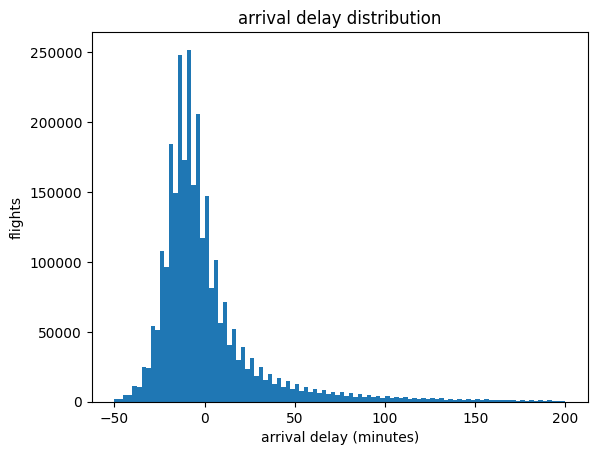

In [4]:
delays = df.filter(pl.col("ARR_DELAY").is_not_null())["ARR_DELAY"].to_list()
plt.hist(delays, bins=100, range=(-50, 200))
plt.xlabel("arrival delay (minutes)")
plt.ylabel("flights")
plt.title("arrival delay distribution")
plt.show()

In [5]:
airport_counts = df.group_by("DEST").agg(pl.len().alias("arrivals")).sort("arrivals", descending=True)
print(airport_counts.head(20))

shape: (20, 2)
┌──────┬──────────┐
│ DEST ┆ arrivals │
│ ---  ┆ ---      │
│ str  ┆ u32      │
╞══════╪══════════╡
│ ATL  ┆ 153569   │
│ DFW  ┆ 129770   │
│ ORD  ┆ 123334   │
│ DEN  ┆ 119592   │
│ CLT  ┆ 95413    │
│ …    ┆ …        │
│ BOS  ┆ 55611    │
│ DCA  ┆ 53501    │
│ EWR  ┆ 52824    │
│ SLC  ┆ 52063    │
│ JFK  ┆ 50268    │
└──────┴──────────┘


In [6]:
df.null_count()

FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,77615,77644,78806,78806,79944,79944,0,79942,86198,0,2920860,0,14,86198,86198,0,2466137,2466137,2466137,2466137,2466137


In [9]:
df.filter(pl.col("ARR_DELAY") > 500).shape

(4101, 32)

In [ ]:
df.group_by("DEST").agg(
    pl.len().alias("arrivals")
).sort("arrivals", descending=True).head(10)

DEST,arrivals
str,u32
"""ATL""",153569
"""DFW""",129770
"""ORD""",123334
"""DEN""",119592
"""CLT""",95413
"""LAX""",85621
"""PHX""",75605
"""LAS""",73462
"""SEA""",70832
